In [1]:
 import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import ElasticNet, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.impute import SimpleImputer
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [2]:
# Step 1: Load and inspect dataset
data  = pd.read_csv('/content/drive/MyDrive/CFYLD.csv', encoding='latin1')

In [3]:
# View first rows
data.head()

,Year,Area(hec),pH,Tot. N (%),Avail. P (ppm),Exch. K (ppm),Org. C (%),Fertilizers,Soil Type,ANN_Temperature,Precipitation(mm/day),Relative_humidity,ANN_ Wind Speed(m/s),Solar_radiation(MJ/mÂ²/day),Soil wetness,Yeild(tone/hect)
0,2001,10982.256830,6.27,0.106,11.22,140.8,1.11,yes,Loamy-sand,32.81,1.26,47.35,4.72,21.75,0.59,2388.0
1,2005,5114.989137,6.16,0.191,11.28,347.3,1.88,yes,Sandy-clay,35.93,2.03,52.48,3.47,21.81,0.64,879.8
2,2005,7894.569177,5.40,0.061,10.85,306.6,0.71,yes,Red sandy-loam,34.87,3.28,65.54,3.51,22.98,0.63,1520.4
3,2010,5361.182751,5.68,0.092,10.98,466.2,1.15,yes,Sandy-clay,34.83,1.88,61.67,9.03,22.15,0.41,1302.6
4,2014,7255.211262,5.81,0.111,13.12,524.1,1.45,yes,Sandy-clay,33.96,2.66,55.44,5.46,22.83,0.52,1115.1


In [4]:
# Check shape (rows, columns)
data.shape

(500, 16)

In [5]:
# Column names
data.columns

Index(['Year', 'Area(hec)', 'pH', 'Tot. N (%)', 'Avail. P (ppm)',
       'Exch. K (ppm)', 'Org. C (%)', 'Fertilizers', 'Soil Type',
       'ANN_Temperature', 'Precipitation(mm/day)', 'Relative_humidity',
       'ANN_ Wind Speed(m/s)', 'Solar_radiation(MJ/mÂ²/day)', 'Soil wetness',
       'Yeild(tone/hect)'],
      dtype='object')

In [6]:
data.describe()

,Year,Area(hec),pH,Tot. N (%),Avail. P (ppm),Exch. K (ppm),Org. C (%),ANN_Temperature,Precipitation(mm/day),Relative_humidity,ANN_ Wind Speed(m/s),Solar_radiation(MJ/mÂ²/day),Soil wetness,Yeild(tone/hect)
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,2007.674000,11134.119884,5.830520,0.128852,11.153820,304.082800,1.198600,34.471400,2.510280,55.540680,5.807520,22.244720,0.554760,2515.853600
std,4.802693,3971.363509,0.482003,0.039617,2.241483,157.352487,0.396071,1.450543,0.852354,6.132361,2.035295,0.731636,0.086644,1219.051845
min,2000.000000,4202.352207,5.000000,0.060000,7.000000,91.400000,0.510000,32.000000,1.110000,45.000000,2.310000,21.000000,0.400000,518.200000
25%,2003.000000,7789.829915,5.430000,0.093000,9.285000,147.575000,0.867500,33.160000,1.727500,50.362500,4.075000,21.597500,0.480000,1631.775000
50%,2007.000000,10971.602425,5.815000,0.132000,11.170000,319.200000,1.190000,34.465000,2.530000,55.665000,5.680000,22.230000,0.560000,2383.400000
75%,2012.000000,13993.562982,6.240000,0.161000,13.062500,425.050000,1.520000,35.732500,3.270000,60.915000,7.662500,22.892500,0.630000,3256.975000
max,2015.000000,20603.301070,6.690000,0.200000,14.990000,597.000000,1.890000,37.000000,4.000000,65.940000,9.400000,23.500000,0.700000,6509.000000


In [7]:
data.describe(include='all')

,Year,Area(hec),pH,Tot. N (%),Avail. P (ppm),Exch. K (ppm),Org. C (%),Fertilizers,Soil Type,ANN_Temperature,Precipitation(mm/day),Relative_humidity,ANN_ Wind Speed(m/s),Solar_radiation(MJ/mÂ²/day),Soil wetness,Yeild(tone/hect)
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500,500,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,yes,Volcanic clay-loam,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,469,106,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,2007.674000,11134.119884,5.830520,0.128852,11.153820,304.082800,1.198600,NaN,NaN,34.471400,2.510280,55.540680,5.807520,22.244720,0.554760,2515.853600
std,4.802693,3971.363509,0.482003,0.039617,2.241483,157.352487,0.396071,NaN,NaN,1.450543,0.852354,6.132361,2.035295,0.731636,0.086644,1219.051845
min,2000.000000,4202.352207,5.000000,0.060000,7.000000,91.400000,0.510000,NaN,NaN,32.000000,1.110000,45.000000,2.310000,21.000000,0.400000,518.200000
25%,2003.000000,7789.829915,5.430000,0.093000,9.285000,147.575000,0.867500,NaN,NaN,33.160000,1.727500,50.362500,4.075000,21.597500,0.480000,1631.775000
50%,2007.000000,10971.602425,5.815000,0.132000,11.170000,319.200000,1.190000,NaN,NaN,34.465000,2.530000,55.665000,5.680000,22.230000,0.560000,2383.400000
75%,2012.000000,13993.562982,6.240000,0.161000,13.062500,425.050000,1.520000,NaN,NaN,35.732500,3.270000,60.915000,7.662500,22.892500,0.630000,3256.975000


In [10]:
# Summary statistics for numerical features
print(data.describe())

              Year     Area(hec)          pH  Tot. N (%)  Avail. P (ppm)  \
count   500.000000    500.000000  500.000000  500.000000      500.000000   
mean   2007.674000  11134.119884    5.830520    0.128852       11.153820   
std       4.802693   3971.363509    0.482003    0.039617        2.241483   
min    2000.000000   4202.352207    5.000000    0.060000        7.000000   
25%    2003.000000   7789.829915    5.430000    0.093000        9.285000   
50%    2007.000000  10971.602425    5.815000    0.132000       11.170000   
75%    2012.000000  13993.562982    6.240000    0.161000       13.062500   
max    2015.000000  20603.301070    6.690000    0.200000       14.990000   

       Exch. K (ppm)  Org. C (%)  ANN_Temperature  Precipitation(mm/day)  \
count     500.000000  500.000000       500.000000             500.000000   
mean      304.082800    1.198600        34.471400               2.510280   
std       157.352487    0.396071         1.450543               0.852354   
min        

In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 16 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Year                         500 non-null    int64  
 1   Area(hec)                    500 non-null    float64
 2   pH                           500 non-null    float64
 3   Tot. N (%)                   500 non-null    float64
 4   Avail. P (ppm)               500 non-null    float64
 5   Exch. K (ppm)                500 non-null    float64
 6   Org. C (%)                   500 non-null    float64
 7   Fertilizers                  500 non-null    object 
 8   Soil Type                    500 non-null    object 
 9   ANN_Temperature              500 non-null    float64
 10  Precipitation(mm/day)        500 non-null    float64
 11  Relative_humidity            500 non-null    float64
 12  ANN_ Wind Speed(m/s)         500 non-null    float64
 13  Solar_radiation(MJ/m

Columns in dataset:
['Year', 'Area(hec)', 'pH', 'Tot. N (%)', 'Avail. P (ppm)', 'Exch. K (ppm)', 'Org. C (%)', 'Fertilizers', 'Soil Type', 'ANN_Temperature', 'Precipitation(mm/day)', 'Relative_humidity', 'ANN_ Wind Speed(m/s)', 'Solar_radiation(MJ/mÂ²/day)', 'Soil wetness', 'Yeild(tone/hect)']


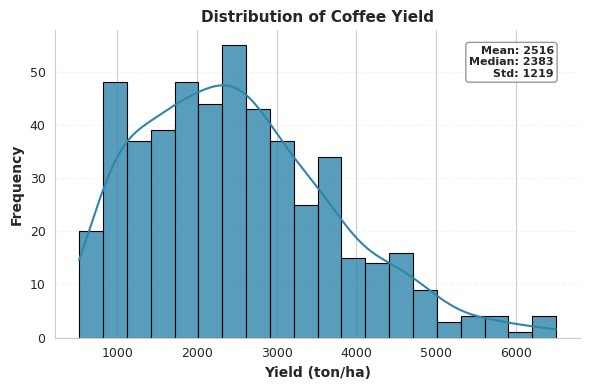


✅ FIG. 4 - HISTOGRAM SAVED

📁 FILE CREATED:
   📄 Fig4_Histogram_Yield.png (600 DPI)

📊 STATISTICS:
   Mean: 2515.85
   Median: 2383.40
   Std Dev: 1219.05


In [9]:
"""
Fig. 4: Histogram Distribution of Coffee Yield
Publication-Ready, Compact
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Check column names
print("Columns in dataset:")
print(data.columns.tolist())

# ============================================================================
# 2. SET PUBLICATION STYLE
# ============================================================================

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica']
plt.rcParams['font.size'] = 10
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['xtick.labelsize'] = 9
plt.rcParams['ytick.labelsize'] = 9
plt.rcParams['savefig.dpi'] = 600
plt.rcParams['savefig.bbox'] = 'tight'
plt.rcParams['savefig.facecolor'] = 'white'

sns.set_style("whitegrid")

# ============================================================================
# 3. CREATE HISTOGRAM
# ============================================================================

plt.figure(figsize=(6, 4), facecolor='white')  # ← Compact

# Histogram with KDE
ax = sns.histplot(
    data['Yeild(tone/hect)'],
    bins=20,
    kde=True,
    color='#2E86AB',
    edgecolor='black',
    linewidth=0.8,
    alpha=0.8,
    stat='count'
)

# Customize
ax.set_title('Distribution of Coffee Yield', fontsize=11, fontweight='bold')
ax.set_xlabel('Yield (ton/ha)', fontsize=10, fontweight='bold')
ax.set_ylabel('Frequency', fontsize=10, fontweight='bold')
ax.tick_params(axis='both', labelsize=9)

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add grid
ax.grid(axis='y', alpha=0.2, linestyle='--')

# Add statistics annotation
mean_val = data['Yeild(tone/hect)'].mean()
median_val = data['Yeild(tone/hect)'].median()
std_val = data['Yeild(tone/hect)'].std()

stats_text = f'Mean: {mean_val:.0f}\nMedian: {median_val:.0f}\nStd: {std_val:.0f}'
ax.text(
    0.95, 0.95,
    stats_text,
    transform=ax.transAxes,
    fontsize=8,
    fontweight='bold',
    verticalalignment='top',
    horizontalalignment='right',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='gray')
)

plt.tight_layout()

# ============================================================================
# 4. SAVE AS PNG (600 DPI)
# ============================================================================

plt.savefig(
    'Fig4_Histogram_Yield.png',
    format='png',
    dpi=600,
    bbox_inches='tight',
    facecolor='white'
)

plt.show()

print("\n" + "="*60)
print("✅ FIG. 4 - HISTOGRAM SAVED")
print("="*60)
print("\n📁 FILE CREATED:")
print("   📄 Fig4_Histogram_Yield.png (600 DPI)")
print(f"\n📊 STATISTICS:")
print(f"   Mean: {mean_val:.2f}")
print(f"   Median: {median_val:.2f}")
print(f"   Std Dev: {std_val:.2f}")
print("="*60)

In [15]:
data['Fertilizers'] = data['Fertilizers'].map({'yes': 1, 'no': 0})
data['Fertilizers'] = data['Fertilizers'].fillna(0)

In [17]:
# Step 3: Define features and target
X = data.drop(columns=['Yeild(tone/hect)', 'Year'])  # drop 'Year' if not useful
y = data['Yeild(tone/hect)']

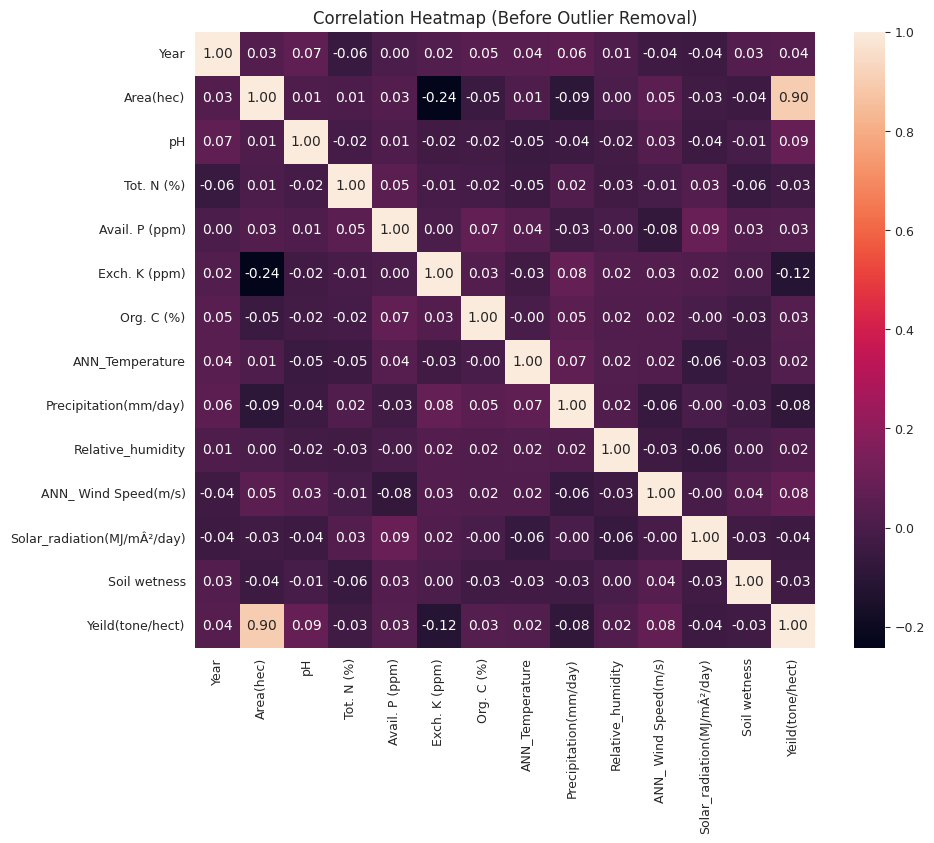

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select only numeric columns (important for heatmap)
num_data = data.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(10,8))
sns.heatmap(num_data.corr(), annot=True, fmt=".2f")
plt.title("Correlation Heatmap (Before Outlier Removal)")
plt.show()

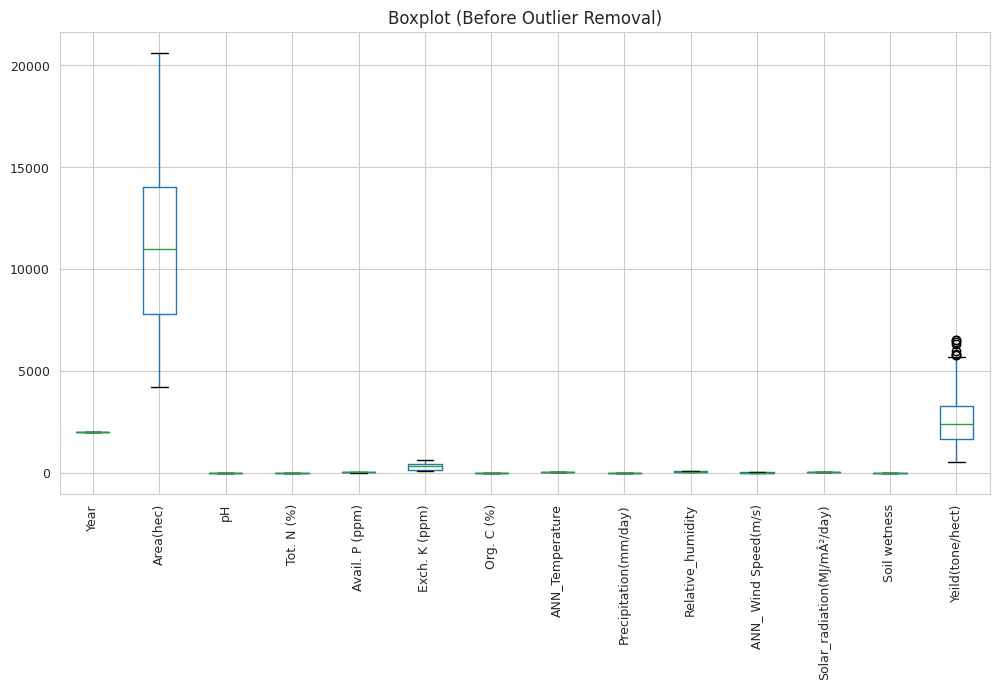

In [14]:
plt.figure(figsize=(12,6))
num_data.boxplot(rot=90)
plt.title("Boxplot (Before Outlier Removal)")
plt.show()

In [18]:
# Step 3: Outlier removal using IQR
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
Q1 = X[numerical_cols].quantile(0.25)
Q3 = X[numerical_cols].quantile(0.75)
IQR = Q3 - Q1
filter_mask = ~((X[numerical_cols] < (Q1 - 1.5 * IQR)) | (X[numerical_cols] > (Q3 + 1.5 * IQR))).any(axis=1)
X = X[filter_mask]
y = y[filter_mask]


In [19]:
# Optional check for Fertilizers column
print(data['Fertilizers'].value_counts(dropna=False))
print(data['Fertilizers'].isnull().sum())

Fertilizers
1    469
0     31
Name: count, dtype: int64
0


In [20]:
# Step 5: Split into train/test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [21]:
# Step 6: Identify column types based on training data
categorical_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()
numeric_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()

In [22]:
# Step 7: Define the preprocessing pipeline

numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_cols),
    ('cat', categorical_transformer, categorical_cols)
])

In [23]:
 # Split into train/test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [24]:
print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (375, 14)
Shape of X_test: (94, 14)
Shape of y_train: (375,)
Shape of y_test: (94,)


In [25]:
data.shape

(500, 16)

In [26]:
print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

Training set size: 375 samples
Testing set size: 94 samples


In [27]:
#  Models
models = {
    'ElasticNet': ElasticNet(random_state=42),
    'RandomForest': RandomForestRegressor(random_state=42),
    'SVR': SVR(),
    'Ridge': Ridge(random_state=42),
    'GBoost': GradientBoostingRegressor(random_state=42),
    'XGBoost': XGBRegressor(random_state=42)
}

In [28]:
# Train model train (default) and perform 5-fold CV
from collections import defaultdict
train_results = defaultdict(dict)
trained_models = {}

for name, model in models.items():
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', model)
    ])
    # Train model train
    pipeline.fit(X_train, y_train)
    trained_models[name] = pipeline



In [29]:
    # Perform 5-fold CV on training data
    cv_scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring='r2')
    train_results[name]['CV R2 Mean'] = cv_scores.mean()
    train_results[name]['CV R2 Std'] = cv_scores.std()

In [30]:
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline

train_results = {}

for name, model in models.items():
    pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('model', model)])
    scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring='r2')
    train_results[name] = {
        'Mean R²': scores.mean(),
        'Std R²': scores.std()
    }
# Display model train CV results
train_results_df = pd.DataFrame(train_results).T.round(4)
train_results_df = train_results_df.sort_values(by='Mean R²', ascending=False)

print("\nModel Train 5-Fold Cross-Validation Results (Training Data):")
print(train_results_df)



Model Train 5-Fold Cross-Validation Results (Training Data):
              Mean R²  Std R²
Ridge          0.8215  0.0490
GBoost         0.8167  0.0372
RandomForest   0.8074  0.0442
XGBoost        0.7766  0.0490
ElasticNet     0.7468  0.0351
SVR           -0.0164  0.0361


In [31]:
# Define refined hyperparameter grids for GridSearchCV
param_grids = {
    'ElasticNet': {
        'regressor__alpha': [0.01, 0.03, 0.05, 0.07, 0.09],
         'regressor__l1_ratio': [0.4, 0.5, 0.6, 0.7],
        'regressor__max_iter': [10000],
        'regressor__tol': [1e-4]
    },
    'Ridge': {
        'regressor__alpha': [0.1, 1.0, 10.0, 100.0],
        'regressor__fit_intercept': [True],
        'regressor__solver': ['auto', 'saga'],
        'regressor__max_iter':  [3000, 5000],
        'regressor__tol': [1e-3, 1e-4],
    },
    'RandomForest': {
        'regressor__n_estimators': [400, 500],
        'regressor__max_depth': [6, 8],
        'regressor__min_samples_split': [5, 7],
        'regressor__min_samples_leaf': [4, 5],
        'regressor__max_features': ['sqrt', 0.2]

    },

    'XGBoost': {
    'regressor__n_estimators': [300, 400],
    'regressor__max_depth': [4, 5],
    'regressor__learning_rate': [0.02, 0.03],
    'regressor__subsample': [0.8, 1.0],
    'regressor__colsample_bytree': [0.7],
},
    'GBoost': {
        'regressor__n_estimators': [300, 350],
        'regressor__learning_rate': [0.03, 0.035],
        'regressor__max_depth': [3, 4],
        'regressor__subsample': [0.9],
        'regressor__min_samples_split': [5, 7],
        'regressor__min_samples_leaf': [4, 5]
    },
    'SVR': {
        'regressor__C': [300, 350, 400],
        'regressor__epsilon': [0.03, 0.04, 0.05],
        'regressor__gamma': ['scale'],
        'regressor__kernel': ['linear']
    }
}


In [32]:
#  Tune all models using GridSearchCV on training data
results = {}
best_models = {}
feature_importances = {}

for name, model in models.items():
    print(f"\n🔍 Tuning {name} with GridSearchCV...")
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', model)
    ])
    try:
        search = GridSearchCV(
            estimator=pipeline,
            param_grid=param_grids[name],
            cv=5,
            scoring='r2',
            refit=True,
            n_jobs=-1 if name != 'XGBoost' else 1,
            verbose=1
        )
        search.fit(X_train, y_train)
        best_models[name] = search.best_estimator_
        results[name] = {
            'Best Params': search.best_params_,
            'CV R2': search.best_score_
        }
        # Store feature importances for tree-based models
        if name in ['RandomForest', 'GBoost', 'XGBoost']:
            feature_importances[name] = search.best_estimator_.named_steps['regressor'].feature_importances_
    except Exception as e:
        print(f"⚠️ Failed to tune {name}: {str(e)}")
        results[name] = {'Error': str(e), 'Model': None}



🔍 Tuning ElasticNet with GridSearchCV...
Fitting 5 folds for each of 20 candidates, totalling 100 fits

🔍 Tuning RandomForest with GridSearchCV...
Fitting 5 folds for each of 32 candidates, totalling 160 fits

🔍 Tuning SVR with GridSearchCV...
Fitting 5 folds for each of 9 candidates, totalling 45 fits

🔍 Tuning Ridge with GridSearchCV...
Fitting 5 folds for each of 32 candidates, totalling 160 fits

🔍 Tuning GBoost with GridSearchCV...
Fitting 5 folds for each of 32 candidates, totalling 160 fits

🔍 Tuning XGBoost with GridSearchCV...
Fitting 5 folds for each of 16 candidates, totalling 80 fits


In [33]:
# Display GridSearchCV tuning results
tuning_results_df = pd.DataFrame(results).T
tuning_results_df = tuning_results_df.dropna().sort_values(by='CV R2', ascending=False)
tuning_results_df['CV R2'] = tuning_results_df['CV R2'].round(4)
print("\n🎯 GridSearchCV Tuning Results (Training Data, 5-fold CV):")
print(tuning_results_df)


🎯 GridSearchCV Tuning Results (Training Data, 5-fold CV):
                                                    Best Params     CV R2
GBoost        {'regressor__learning_rate': 0.03, 'regressor_...  0.826707
ElasticNet    {'regressor__alpha': 0.09, 'regressor__l1_rati...  0.822787
Ridge         {'regressor__alpha': 10.0, 'regressor__fit_int...  0.822775
SVR           {'regressor__C': 350, 'regressor__epsilon': 0....  0.822148
XGBoost       {'regressor__colsample_bytree': 0.7, 'regresso...   0.81515
RandomForest  {'regressor__max_depth': 8, 'regressor__max_fe...  0.797488


In [34]:
# Evaluate all tuned models on the test set (only once)
final_results = defaultdict(dict)
y_preds = {}  # Initialize y_preds dictionary
for name, model in best_models.items():
    if model is not None:
        y_pred = model.predict(X_test)
        final_results[name]['Test RMSE'] = np.sqrt(mean_squared_error(y_test, y_pred))
        final_results[name]['Test MAE'] = mean_absolute_error(y_test, y_pred)
        final_results[name]['Test R2'] = r2_score(y_test, y_pred)
        final_results[name]['CV R2'] = results[name]['CV R2']
        final_results[name]['Best Params'] = results[name]['Best Params']


In [35]:
#  Report final results
final_results_df = pd.DataFrame(final_results).T
if 'Test R2' in final_results_df.columns:
    final_results_df_sorted = final_results_df.sort_values(by='Test R2', ascending=False)
    print("\n Final Tuned Model Performance (Test Set):")
    print(final_results_df_sorted[['Test R2', 'Test RMSE', 'Test MAE', 'CV R2']])
    best_model_name = final_results_df_sorted.index[0]
    print(f"\n🌟 Best Model: {best_model_name}")
    print(f"Best Parameters:\n{final_results_df_sorted.loc[best_model_name, 'Best Params']}")


 Final Tuned Model Performance (Test Set):
               Test R2   Test RMSE    Test MAE     CV R2
Ridge         0.843067  519.366459  377.487576  0.822775
ElasticNet     0.84173  521.575444  378.539536  0.822787
SVR           0.839959  524.485214  385.938184  0.822148
GBoost        0.837733  528.119425  382.465668  0.826707
XGBoost       0.823832  550.276607  400.109346   0.81515
RandomForest  0.763547  637.514691  462.953528  0.797488

🌟 Best Model: Ridge
Best Parameters:
{'regressor__alpha': 10.0, 'regressor__fit_intercept': True, 'regressor__max_iter': 3000, 'regressor__solver': 'saga', 'regressor__tol': 0.0001}


In [36]:
# Display feature importances for all models
feature_names = (numeric_cols +
                 list(best_models[list(best_models.keys())[0]].named_steps['preprocessor']
                      .named_transformers_['cat']
                      .named_steps['onehot']
                      .get_feature_names_out(categorical_cols)))

for name in models.keys():
    if name in feature_importances:
        print(f"\nFeature Importances for {name}:")
        importances = pd.Series(feature_importances[name], index=feature_names).sort_values(ascending=False)
        print(importances.head(12))  # Top 10 features


Feature Importances for RandomForest:
Area(hec)                       0.416786
Soil Type_Sandy-clay            0.156168
Soil Type_Brown clay            0.155134
Exch. K (ppm)                   0.074040
Soil Type_Red sandy-loam        0.029577
Precipitation(mm/day)           0.021316
Relative_humidity               0.017952
pH                              0.017948
Soil Type_Volcanic clay-loam    0.015187
ANN_Temperature                 0.014294
ANN_ Wind Speed(m/s)            0.013113
Org. C (%)                      0.012424
dtype: float64

Feature Importances for GBoost:
Area(hec)                0.829047
pH                       0.032349
Exch. K (ppm)            0.023280
Soil Type_Brown clay     0.018769
ANN_ Wind Speed(m/s)     0.012633
Org. C (%)               0.011823
Precipitation(mm/day)    0.011548
Relative_humidity        0.010511
ANN_Temperature          0.009376
Soil Type_Sandy-clay     0.009013
Tot. N (%)               0.007881
Soil wetness             0.006458
dtype: float6

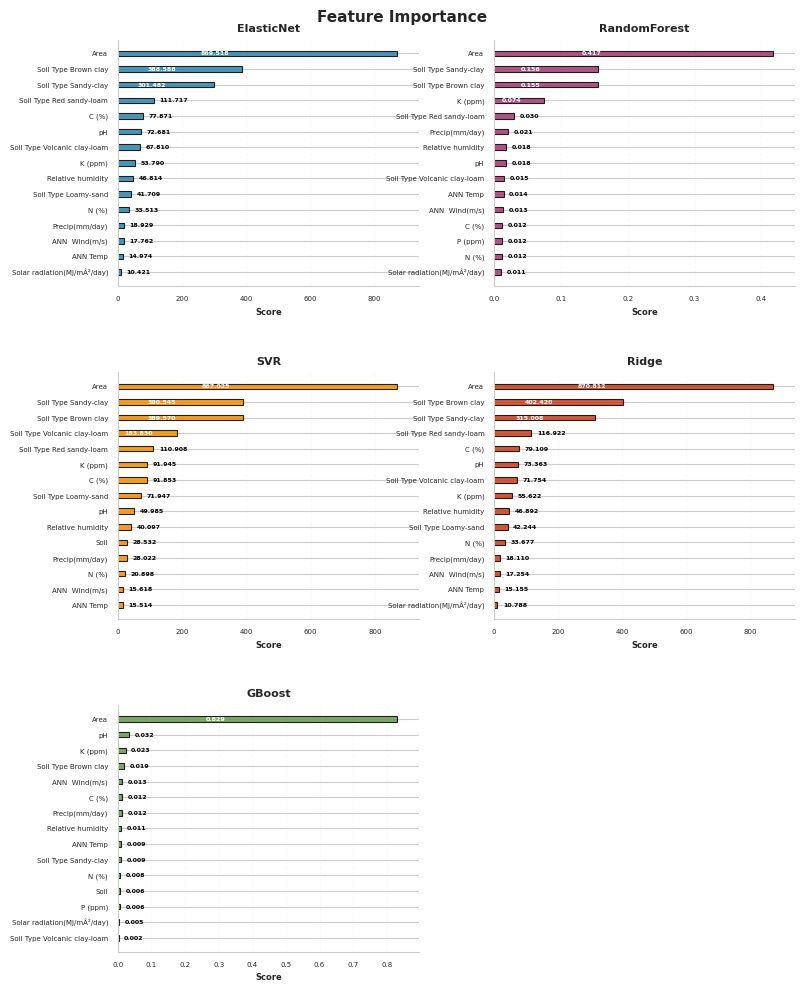


✅ ULTRA-COMPACT FIG. 7 SAVED

📁 FILE CREATED:
   📄 Fig7_Feature_Importance.png (600 DPI)

💡 ULTRA-COMPACT SETTINGS:
   ✅ Figure size: 8 x 10 inches
   ✅ 15 features per model (ALL)
   ✅ Bar height: 0.35 (thinnest)
   ✅ Font size: 4.5-8 pt
   ✅ Minimal grid
   ✅ Maximum space saving


In [37]:
"""
Fig. 7: Feature Importance Analysis Across All Models
ULTRA-COMPACT BAR PLOT - All Features Included (15 per model)
Maximum Space Saving, Clean Design
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================================
# 1. SET ULTRA-COMPACT STYLE
# ============================================================================

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica']
plt.rcParams['font.size'] = 5
plt.rcParams['axes.labelsize'] = 6
plt.rcParams['axes.titlesize'] = 8
plt.rcParams['xtick.labelsize'] = 5
plt.rcParams['ytick.labelsize'] = 5
plt.rcParams['savefig.dpi'] = 600
plt.rcParams['savefig.bbox'] = 'tight'
plt.rcParams['savefig.facecolor'] = 'white'

sns.set_style("whitegrid")

# ============================================================================
# 2. GET CLEANED FEATURE NAMES
# ============================================================================

feature_names = []
for name in best_models['Ridge'].named_steps['preprocessor'].get_feature_names_out():
    if name.startswith('num__'):
        feature_names.append(name[5:])
    elif name.startswith('cat__'):
        feature_names.append(name[5:])
    else:
        feature_names.append(name)

# ============================================================================
# 3. CREATE ULTRA-COMPACT FIGURE
# ============================================================================

# SMALLEST figure size
plt.figure(figsize=(8, 10), facecolor='white')  # ← SMALLEST

# Define colors
model_colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#6A994E', '#BC4B51']

# Create subplots (3 rows, 2 columns)
for i, (name, model) in enumerate(best_models.items(), 1):
    ax = plt.subplot(3, 2, i)

    # Get feature importances/coefficients
    if name in ['Ridge', 'ElasticNet', 'SVR']:
        coef = model.named_steps['regressor'].coef_
        if len(coef.shape) > 1:
            coef = coef[0]
        importances = np.abs(coef)
    else:
        importances = model.named_steps['regressor'].feature_importances_

    # Sort and select ALL TOP 15 FEATURES
    indices = np.argsort(importances)[-15:]  # ← 15 features (ALL)
    sorted_features = [feature_names[i] for i in indices]
    sorted_importances = importances[indices]

    # SHORTEST feature names (2-4 characters)
    display_names = []
    for fname in sorted_features:
        fname_clean = fname.replace('_', ' ')
        fname_clean = fname_clean.replace('(hec)', '')
        fname_clean = fname_clean.replace('Annual', '')
        fname_clean = fname_clean.replace('Temperature', 'Temp')
        fname_clean = fname_clean.replace('Precipitation', 'Precip')
        fname_clean = fname_clean.replace('Relative Humidity', 'RH')
        fname_clean = fname_clean.replace('Wind Speed', 'Wind')
        fname_clean = fname_clean.replace('Solar Radiation', 'Solar')
        fname_clean = fname_clean.replace('Soil wetness', 'Soil')
        fname_clean = fname_clean.replace('Tot. N', 'N')
        fname_clean = fname_clean.replace('Avail. P', 'P')
        fname_clean = fname_clean.replace('Exch. K', 'K')
        fname_clean = fname_clean.replace('Org. C', 'C')
        fname_clean = fname_clean.strip()
        display_names.append(fname_clean)

    # Horizontal bar plot (THINNEST bars)
    bars = ax.barh(
        display_names,
        sorted_importances,
        height=0.35,                    # ← THINNEST bars
        color=model_colors[i-1],
        edgecolor='black',
        linewidth=0.8,
        alpha=0.85
    )

    # Add value labels (SMALLEST)
    max_val = max(sorted_importances)
    for bar, val in zip(bars, sorted_importances):
        if val > max_val * 0.15:
            x_pos = val * 0.35
            ha = 'center'
            color = 'white'
        else:
            x_pos = val + (max_val * 0.02)
            ha = 'left'
            color = 'black'

        ax.text(
            x_pos,
            bar.get_y() + bar.get_height()/2,
            f'{val:.3f}',
            va='center',
            ha=ha,
            fontsize=4.5,               # ← SMALLEST
            fontweight='bold',
            color=color
        )

    # Customize subplot
    ax.set_title(f'{name}', fontsize=8, fontweight='bold')
    ax.set_xlabel('Score', fontsize=6, fontweight='bold')
    ax.set_ylabel('')
    ax.tick_params(axis='both', labelsize=5)

    # Remove top and right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Remove grid (saves space)
    ax.grid(axis='x', alpha=0.1, linestyle='--')

    # Set x-axis limits
    ax.set_xlim(0, max_val * 1.08)

# Remove unused subplot
plt.subplot(3, 2, 6)
plt.gca().set_visible(False)

# Main title (SMALL)
plt.suptitle(
    'Feature Importance',
    fontsize=11,
    fontweight='bold',
    y=0.98
)

# Adjust layout with minimal spacing
plt.tight_layout()
plt.subplots_adjust(top=0.95, hspace=0.35, wspace=0.25)

# ============================================================================
# 4. SAVE AS PNG (600 DPI)
# ============================================================================

plt.savefig(
    'Fig7_Feature_Importance.png',
    format='png',
    dpi=600,
    bbox_inches='tight',
    facecolor='white'
)

plt.show()

print("\n" + "="*60)
print("✅ ULTRA-COMPACT FIG. 7 SAVED")
print("="*60)
print("\n📁 FILE CREATED:")
print("   📄 Fig7_Feature_Importance.png (600 DPI)")
print("\n💡 ULTRA-COMPACT SETTINGS:")
print("   ✅ Figure size: 8 x 10 inches")
print("   ✅ 15 features per model (ALL)")
print("   ✅ Bar height: 0.35 (thinnest)")
print("   ✅ Font size: 4.5-8 pt")
print("   ✅ Minimal grid")
print("   ✅ Maximum space saving")
print("="*60)

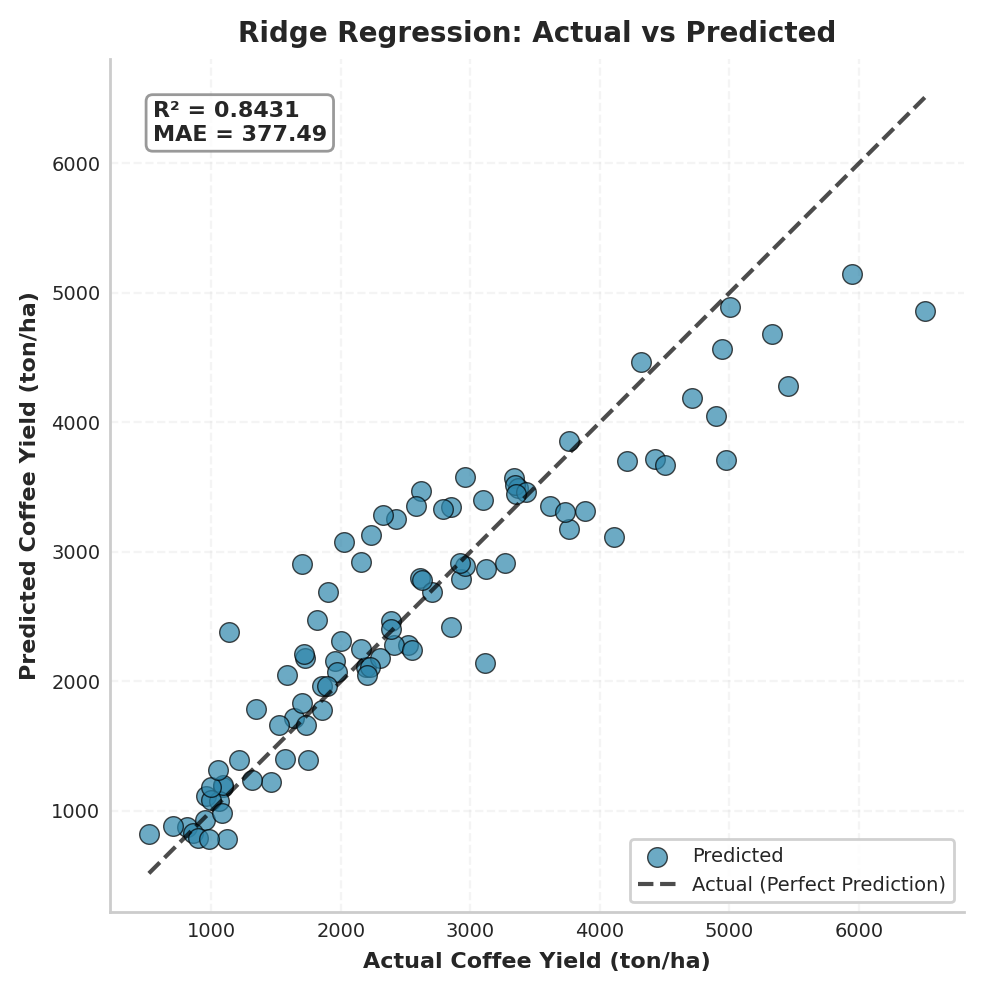


✅ FIG. 8 - ACTUAL VS PREDICTED (RIDGE)

📁 FILE CREATED:
   📄 Fig8_Actual_vs_Predicted_Ridge.png (600 DPI)

📊 METRICS:
   R² = 0.8431
   MAE = 377.49


In [ ]:
"""
Fig. 8: Actual vs Predicted Values - Ridge Regression
Compact, Publication-Ready
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, r2_score

# ============================================================================
# 1. SET PUBLICATION STYLE
# ============================================================================

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica']
plt.rcParams['font.size'] = 8
plt.rcParams['axes.labelsize'] = 8
plt.rcParams['axes.titlesize'] = 10
plt.rcParams['xtick.labelsize'] = 7
plt.rcParams['ytick.labelsize'] = 7
plt.rcParams['savefig.dpi'] = 600
plt.rcParams['savefig.bbox'] = 'tight'
plt.rcParams['savefig.facecolor'] = 'white'

sns.set_style("whitegrid")

# ============================================================================
# 2. PLOT ACTUAL VS PREDICTED (RIDGE ONLY)
# ============================================================================

# Create figure (compact)
plt.figure(figsize=(6, 5), facecolor='white')  # ← Small, compact

# Ridge Regression
name = 'Ridge'
model = best_models['Ridge']
y_pred = model.predict(X_test)

# Calculate metrics
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Scatter plot
ax = plt.subplot(1, 1, 1)

ax.scatter(
    y_test, y_pred,
    alpha=0.7,
    color='#2E86AB',
    edgecolor='black',
    linewidth=0.5,
    s=50,
    label='Predicted'
)

# Perfect prediction line (Actual)
val_range = [min(y_test.min(), y_pred.min()),
             max(y_test.max(), y_pred.max())]
ax.plot(val_range, val_range, 'k--',
        linewidth=1.5,
        alpha=0.7,
        label='Actual (Perfect Prediction)')

# Add metrics box
metrics_text = f'R² = {r2:.4f}\nMAE = {mae:.2f}'
ax.text(
    0.05, 0.95,
    metrics_text,
    transform=ax.transAxes,
    fontsize=8,
    fontweight='bold',
    verticalalignment='top',
    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='gray')
)

# Customize
ax.set_title('Ridge Regression: Actual vs Predicted', fontsize=10, fontweight='bold')
ax.set_xlabel('Actual Coffee Yield (ton/ha)', fontsize=8, fontweight='bold')
ax.set_ylabel('Predicted Coffee Yield (ton/ha)', fontsize=8, fontweight='bold')
ax.tick_params(axis='both', labelsize=7)

# Equal aspect ratio
ax.set_aspect('equal', adjustable='box')

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Grid
ax.grid(alpha=0.2, linestyle='--')

# Legend
ax.legend(loc='lower right', fontsize=7, frameon=True, framealpha=0.9)

plt.tight_layout()

# ============================================================================
# 4. SAVE AS PNG (600 DPI)
# ============================================================================

plt.savefig(
    'Fig8_Actual_vs_Predicted_Ridge.png',
    format='png',
    dpi=600,
    bbox_inches='tight',
    facecolor='white'
)

plt.show()

print("\n" + "="*60)
print("✅ FIG. 8 - ACTUAL VS PREDICTED (RIDGE)")
print("="*60)
print("\n📁 FILE CREATED:")
print("   📄 Fig8_Actual_vs_Predicted_Ridge.png (600 DPI)")
print(f"\n📊 METRICS:")
print(f"   R² = {r2:.4f}")
print(f"   MAE = {mae:.2f}")
print("="*60)

========================================================================================